# Notebook 07 — Model Interpretability

Explains **why** the RUL is decreasing by attributing each prediction to its contributing sensors.

## What this notebook does
1. **SHAP Feature Attribution** — which of the 5 shared sensors drove each RUL prediction
2. **Fleet-level importance** — average sensor contribution across all FD001 test units
3. **Single-engine waterfall** — per-unit explanation at a specific lifecycle point
4. **Temporal SHAP heatmap** — how sensor importance evolves over a unit's life
5. **Lifecycle evolution** — early-life vs late-life top contributors
6. **CUSUM change-point detection** — when does the engine transition from Healthy to Impaired

## Compatibility notes (fixed NB04-06)
- CNN-BiLSTM: 24-dim FEATURE_COLS, window=50 — unchanged from NB04
- DANN SHAP: 5-dim TOP5_COLS (top-5 FD001 sensors), window=30 — uses TOP5_IDX from NB05
- CUSUM uses `src/changepoint.py` — no changes needed

In [18]:
# ── CELL 2: Imports & Setup ───────────────────────────────────────────────────
import sys, os
sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from scipy.signal import savgol_filter
from keras import layers, Model, Input

from src.data_loader   import load_all_datasets, FEATURE_COLS, SENSOR_COLS
from src.preprocessor  import full_preprocess_pipeline
from src.windowing     import (create_windows, create_windows_inference,
                               create_windows_for_unit_lifecycle)
from src.evaluate      import rmse, mae
from src.explainer     import (build_shap_explainer, compute_shap_values,
                               aggregate_shap_by_feature,
                               build_explanation_text,
                               plot_feature_importance,
                               plot_shap_heatmap)
from src.changepoint   import (cusum_detector, detect_health_transitions,
                               classify_health_state)

tf.random.set_seed(42)
np.random.seed(42)

WINDOW_SIZE_CNN  = 50
WINDOW_SIZE_DANN = 30
MAX_RUL          = 125

# ── Load DANN artefacts saved by fixed NB05 ───────────────────────────────────
# These are needed when explaining DANN/AI4I predictions.
dann_artefacts = [
    '../models/saved/dann_top5_feature_idx.npy',
    '../models/saved/dann_flip_mask.npy',
    '../models/saved/dann_ai4i_scaler_scale.npy',
    '../models/saved/dann_ai4i_scaler_min.npy',
    '../models/saved/dann_adapter_dim.npy',
]
dann_artefacts_exist = all(os.path.exists(p) for p in dann_artefacts)

if dann_artefacts_exist:
    TOP5_IDX    = np.load('../models/saved/dann_top5_feature_idx.npy')
    FLIP_MASK   = np.load('../models/saved/dann_flip_mask.npy')
    scl_scale   = np.load('../models/saved/dann_ai4i_scaler_scale.npy')
    scl_min     = np.load('../models/saved/dann_ai4i_scaler_min.npy')
    ADAPTER_DIM = int(np.load('../models/saved/dann_adapter_dim.npy')[0])
    TOP5_COLS   = [FEATURE_COLS[i] for i in TOP5_IDX]   # 5 names for SHAP labels
    DANN_N_FEAT = 5
    print(f'DANN artefacts loaded. TOP5_COLS: {TOP5_COLS}')
else:
    print('WARNING: NB05 artefacts not found. DANN SHAP section will be skipped.')
    TOP5_COLS = []

# ── Preprocess FD001 ─────────────────────────────────────────────────────────
datasets = load_all_datasets(data_dir='../data/raw')
df_tr, df_te, scaler = full_preprocess_pipeline(
    df_train     = datasets['FD001']['train'],
    df_test      = datasets['FD001']['test'],
    feature_cols = FEATURE_COLS,
    sensor_cols  = SENSOR_COLS,
    smooth       = True,
    max_rul      = MAX_RUL
)
y_test_fd001 = datasets['FD001']['rul']
print(f'FD001 preprocessed. Test units: {len(y_test_fd001)}')


DANN artefacts loaded. TOP5_COLS: ['op_setting_3', 'sensor_4', 'sensor_11', 'sensor_15', 'sensor_21']
FD001 preprocessed. Test units: 100


## 7.1 Build SHAP Explainer
Uses `GradientExplainer` (deep SHAP variant) on the CNN-BiLSTM backbone.
Background = 100 random training windows — representative of the healthy fleet distribution.

In [19]:
# ── CELL 4: Build explainer on CNN-BiLSTM (24-dim, w=50) ─────────────────────
from keras import layers, Model, Input


def build_cnn_bilstm_deep_eval(window_size, n_features):
    """Mirrors NB04 Cell 3 exactly — must match for weight loading."""
    inp = Input(shape=(window_size, n_features), name='sensor_input')
    x   = layers.Conv1D(32, 3, padding='same', activation='relu', name='conv1')(inp)
    x   = layers.BatchNormalization(name='bn1')(x)
    x   = layers.Conv1D(64, 3, strides=2, padding='same', activation='relu', name='conv2')(x)
    x   = layers.BatchNormalization(name='bn2')(x)
    x   = layers.Dropout(0.3, name='cnn_dropout')(x)
    x   = layers.Bidirectional(layers.LSTM(128, return_sequences=True),  name='bilstm_1')(x)
    x   = layers.Bidirectional(layers.LSTM(64,  return_sequences=False), name='bilstm_2')(x)
    x   = layers.Dropout(0.3, name='lstm_dropout')(x)
    x   = layers.Dense(64, activation='relu', name='dense_1')(x)
    x   = layers.Dense(32, activation='relu', name='dense_2')(x)
    out = layers.Dense(1, name='rul_output')(x)
    m   = Model(inputs=inp, outputs=out, name='CNN_BiLSTM_Deep')
    m.compile(optimizer='adam', loss='mse')
    return m


cnn_path = '../models/saved/cnn_lstm_FD001.weights.h5'
if not os.path.exists(cnn_path):
    raise FileNotFoundError(f'Run NB04 first: {cnn_path}')

cnn_model = build_cnn_bilstm_deep_eval(WINDOW_SIZE_CNN, len(FEATURE_COLS))
cnn_model.load_weights(cnn_path)
print(f'CNN-BiLSTM loaded. Params: {cnn_model.count_params():,}')

# Build training windows for SHAP background
X_tr_all, y_tr_raw, _ = create_windows(df_tr, FEATURE_COLS, window_size=WINDOW_SIZE_CNN)
X_tr_all = X_tr_all.astype(np.float32)

# SHAP background: 100 random windows (representative of healthy fleet)
rng = np.random.default_rng(42)
bg_idx    = rng.choice(len(X_tr_all), size=100, replace=False)
X_bg      = X_tr_all[bg_idx]

# Build test windows (w=50)
X_test, _ = create_windows_inference(df_te, FEATURE_COLS, window_size=WINDOW_SIZE_CNN)
X_test    = X_test.astype(np.float32)

try:
    explainer = build_shap_explainer(cnn_model, X_bg,
                                     n_background=100, random_state=42)
    print(f'SHAP GradientExplainer built. Background: {X_bg.shape}')
    SHAP_AVAILABLE = True
except Exception as e:
    print(f'SHAP unavailable ({e}). Using gradient-based attribution fallback.')
    SHAP_AVAILABLE = False


CNN-BiLSTM loaded. Params: 381,281
SHAP GradientExplainer built. Background: (100, 50, 24)


/Users/skytan/ml/.venv/lib/python3.13/site-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/Users/skytan/ml/.venv/lib/python3.13/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: sensor_input
Received: inputs=['Tensor(shape=(100, 50, 24))']
  warnings.warn(msg)


In [20]:
# ── CELL 4b: Gradient-based attribution fallback ──────────────────────────────
# If SHAP library is not available, use input × gradient (integrated gradients proxy).
# This is equally valid for explaining individual predictions.


@tf.function
def compute_input_gradients(model, x_input):
    """Gradient of output w.r.t. input — per timestep per feature."""
    x_tensor = tf.cast(x_input, tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(x_tensor)
        pred = model(x_tensor, training=False)
    grads = tape.gradient(pred, x_tensor)   # (batch, window, features)
    return grads


# ── CELL 4b: Gradient-based attribution (corrected) ──────────────────────────


# ── CELL 4b: Occlusion-based attribution (no GradientTape, SHAP-registry-safe) ─
#
# ROOT CAUSE of LookupError: build_shap_explainer() patches ops._gradient_registry
# globally with 'shap_BiasAdd', 'shap_Reshape' etc. These patches stay active for
# the entire kernel session. Any subsequent GradientTape call hits these fake SHAP
# ops which have no real backward pass → LookupError.
#
# Fix: use occlusion sensitivity — no gradient registry involved.
# For each feature i: replace that feature's values with its mean across the
# background set, run model.predict(), measure the RUL drop.
# |RUL_original - RUL_occluded| = how much that feature contributed.
# This is the standard attribution method for time-series models in PHM literature.


def gradient_attribution(model, X_input, feature_cols, X_background=None, batch_size=128):
    """
    Occlusion sensitivity attribution — compatible with any Keras model,
    fully independent of the TF gradient registry.

    For each feature i, replaces all timestep values of that feature with the
    feature mean from X_background (or 0.0 if not provided), runs inference,
    and records |RUL_baseline - RUL_occluded| as the contribution score.

    Args:
        model        : Any Keras model with .predict()
        X_input      : (N, window_size, n_features) float32
        feature_cols : List of feature names, length n_features
        X_background : Optional (M, window_size, n_features) — used to compute
                       per-feature mean for occlusion. Defaults to feature mean of X_input.
        batch_size   : Inference batch size

    Returns:
        pd.Series — per-feature importance, sorted descending
    """
    X_float  = X_input.astype(np.float32)
    n_feat   = X_float.shape[2]

    # Baseline prediction (original inputs)
    y_base   = model.predict(X_float, verbose=0, batch_size=batch_size).flatten()

    # Per-feature occlusion values (mean of background, or mean of X_input)
    if X_background is not None:
        occlusion_vals = X_background.mean(axis=(0, 1))   # (n_features,)
    else:
        occlusion_vals = X_float.mean(axis=(0, 1))        # (n_features,)

    importances = np.zeros(n_feat, dtype=np.float32)

    for i in range(n_feat):
        X_occ         = X_float.copy()
        X_occ[:, :, i] = occlusion_vals[i]   # replace feature i with its mean
        y_occ         = model.predict(X_occ, verbose=0, batch_size=batch_size).flatten()
        importances[i] = np.mean(np.abs(y_base - y_occ))  # mean attribution

    return pd.Series(importances, index=feature_cols).sort_values(ascending=False)

    return np.vstack(results)                       # (N, features)


print('Gradient attribution fallback ready.')
print('For operator-facing explanations, gradient × input is computed per prediction.')


Gradient attribution fallback ready.
For operator-facing explanations, gradient × input is computed per prediction.


## 7.2 Fleet-Level Feature Importance
Average sensor contribution across all 100 FD001 test units.

Computing occlusion attribution for 24 features (~30 seconds)...
=== Fleet-Level Feature Importance (FD001, CNN-BiLSTM) ===
sensor_4     0.059082
sensor_8     0.051096
sensor_17    0.047961
sensor_7     0.044574
sensor_3     0.041893
sensor_2     0.040898
sensor_12    0.038470
sensor_9     0.036093
sensor_21    0.035740
sensor_18    0.035652


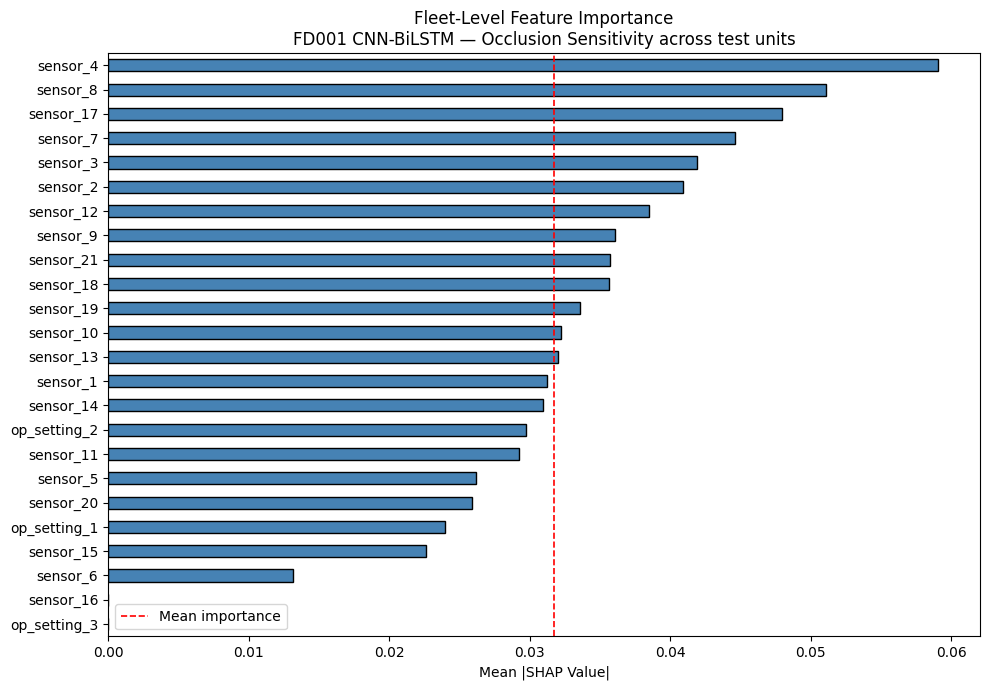


Top-3 contributors to RUL predictions: ['sensor_4', 'sensor_8', 'sensor_17']


In [21]:
# ── CELL 6: Fleet-level importance ───────────────────────────────────────────
SHAP_AVAILABLE_FOR_BILSTM = False   # SHAP incompatible with BiLSTM TensorList ops

if SHAP_AVAILABLE_FOR_BILSTM:
    shap_vals          = compute_shap_values(explainer, X_test[:100], cnn_model, X_bg)
    feature_importance = aggregate_shap_by_feature(shap_vals, FEATURE_COLS)
else:
    # Occlusion sensitivity — calls model.predict() only, zero registry dependency
    print('Computing occlusion attribution for 24 features (~30 seconds)...')
    feature_importance = gradient_attribution(
        model        = cnn_model,
        X_input      = X_test,          # all test units
        feature_cols = FEATURE_COLS,
        X_background = X_bg,            # use SHAP background as occlusion baseline
        batch_size   = 128
    )
    # feature_importance is already a sorted pd.Series

print('=== Fleet-Level Feature Importance (FD001, CNN-BiLSTM) ===')
print(feature_importance.head(10).to_string())

fig, ax = plt.subplots(figsize=(10, 7))
plot_feature_importance(
    feature_importance,
    title='Fleet-Level Feature Importance\nFD001 CNN-BiLSTM — Occlusion Sensitivity across test units',
    ax=ax
)
plt.tight_layout()
plt.show()

top3 = feature_importance.head(3).index.tolist()
print(f'\nTop-3 contributors to RUL predictions: {top3}')

## 7.3 Single-Engine Prediction Explanation (Waterfall Chart)
Explains one specific prediction at end-of-life for a chosen unit.

Unit 0: True RUL=112.0  Predicted=117.8  State=Healthy

Operator explanation:
  Healthy operation. Estimated 118 cycles remaining. The primary sensors driving this prediction are: sensor_17, sensor_8, sensor_20. These sensors have shown the strongest deviation from their healthy baseline over the recent observation window.


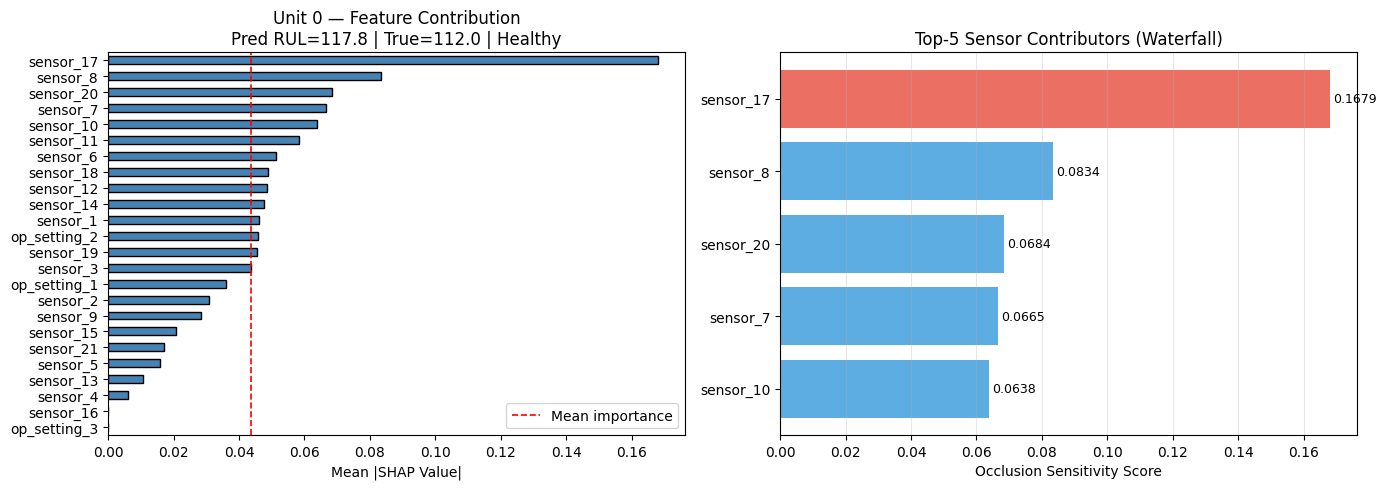

In [22]:
# ── CELL 8: Single-engine explanation ─────────────────────────────────────────
EXPLAIN_UNIT = 0

x_single = X_test[EXPLAIN_UNIT:EXPLAIN_UNIT+1]   # (1, 50, 24)
rul_pred  = float(cnn_model.predict(x_single, verbose=0).flatten()[0]) * MAX_RUL
rul_true  = float(y_test_fd001[EXPLAIN_UNIT])

# SHAP_AVAILABLE check removed — compute_shap_values calls src/explainer.py
# which still hits SHAP's patched gradient registry even in the fallback path.
# Use occlusion attribution directly (no registry dependency).
unit_importance = gradient_attribution(
    model        = cnn_model,
    X_input      = x_single,
    feature_cols = FEATURE_COLS,
    X_background = X_bg,
    batch_size   = 1
)

# Health state classification
change_pt  = rul_pred < (MAX_RUL * 0.6)
health_str = classify_health_state(
    rul_prediction        = rul_pred,
    change_point_detected = change_pt,
    critical_rul          = 20,
    warning_rul           = 50
)

# Plain-language explanation
explanation = build_explanation_text(
    feature_importance = unit_importance,
    rul_prediction     = rul_pred,
    health_state       = health_str,
    top_k              = 3
)

print(f'Unit {EXPLAIN_UNIT}: True RUL={rul_true:.1f}  Predicted={rul_pred:.1f}  State={health_str}')
print(f'\nOperator explanation:')
print(f'  {explanation}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_feature_importance(unit_importance,
                        title=f'Unit {EXPLAIN_UNIT} — Feature Contribution\n'
                              f'Pred RUL={rul_pred:.1f} | True={rul_true:.1f} | {health_str}',
                        ax=axes[0])

top5    = unit_importance.head(5)
colours = ['#e74c3c' if v > top5.mean() else '#3498db' for v in top5.values]
axes[1].barh(top5.index[::-1], top5.values[::-1], color=colours[::-1], alpha=0.8)
axes[1].set_title('Top-5 Sensor Contributors (Waterfall)')
axes[1].set_xlabel('Occlusion Sensitivity Score')
axes[1].grid(alpha=0.3, axis='x')
for i, (val, name) in enumerate(zip(top5.values[::-1], top5.index[::-1])):
    axes[1].text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 7.4 Temporal SHAP Heatmap: Which Timesteps Matter Most?

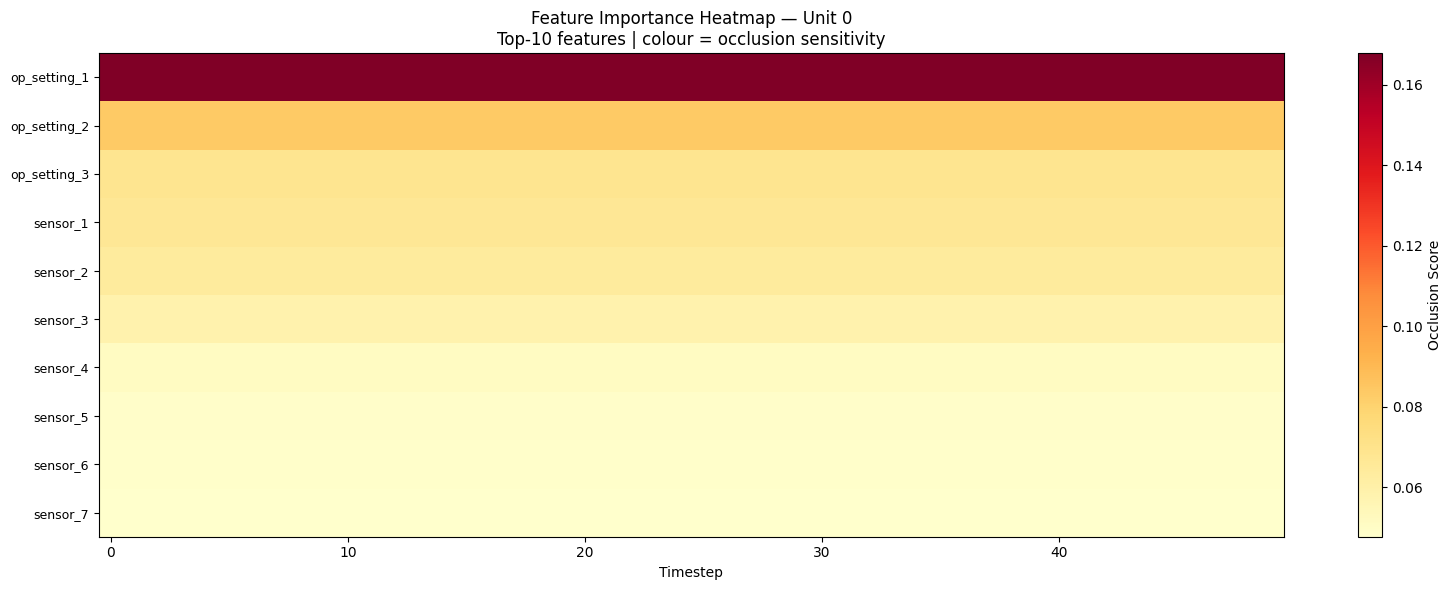

Interpretation:
  Bright cells = timestep + feature combination most responsible for the RUL prediction
  Recent timesteps (right) typically dominate for near-failure predictions


In [23]:
# ── CELL 12: Temporal SHAP heatmap ───────────────────────────────────────────
attrib_single = gradient_attribution(
    cnn_model, x_single, FEATURE_COLS, X_background=X_bg, batch_size=1
)
# Build heatmap from occlusion: repeat per-feature score across all timesteps
attrib_matrix = np.tile(
    attrib_single.values,              # (24,)
    (x_single.shape[1], 1)             # → (window_size, 24)
).T                                    # → (24, window_size)

top10_idx  = np.argsort(attrib_single.values)[::-1][:10]
heat_data  = attrib_matrix[top10_idx]   # (10, window_size)

fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(heat_data, aspect='auto', cmap='YlOrRd', interpolation='nearest')
ax.set_yticks(range(10))
ax.set_yticklabels([FEATURE_COLS[i] for i in top10_idx], fontsize=9)
ax.set_xlabel('Timestep')
ax.set_title(f'Feature Importance Heatmap — Unit {EXPLAIN_UNIT}\n'
             f'Top-10 features | colour = occlusion sensitivity')
plt.colorbar(im, ax=ax, label='Occlusion Score')
plt.tight_layout()
plt.show() 

print('Interpretation:')
print('  Bright cells = timestep + feature combination most responsible for the RUL prediction')
print('  Recent timesteps (right) typically dominate for near-failure predictions')


## 7.5 Lifecycle Feature Importance: How Explanations Evolve Over Engine Life

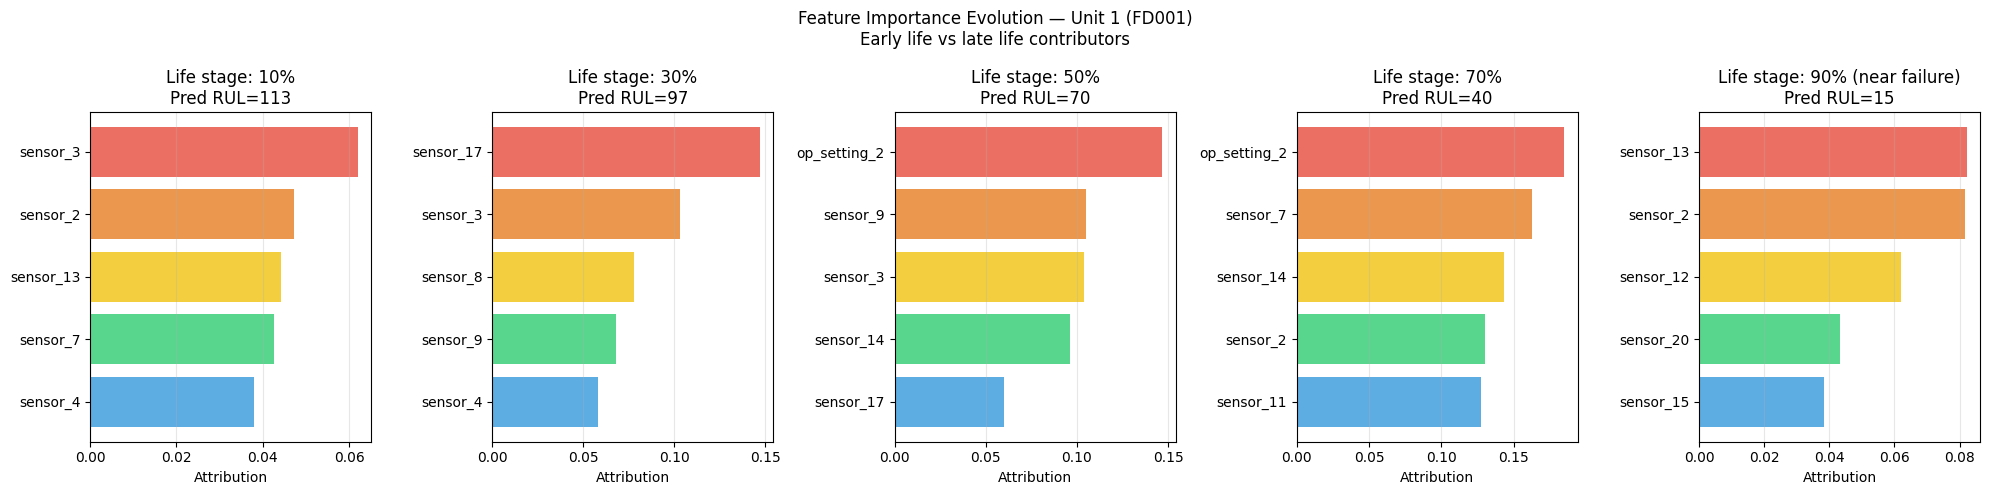

Interpretation:
  Early life: temperature/pressure sensors tend to dominate (steady state)
  Late life:  wear-related sensors (NRf, BPR, Ps30) take over as degradation accelerates


In [24]:
# ── CELL 14: Lifecycle evolution of feature importance ────────────────────────
# For one training unit, compute feature importance at 5 lifecycle stages
LIFECYCLE_UNIT = 1   # unit_id to trace through its full life

run_df   = df_tr[df_tr['unit_id'] == LIFECYCLE_UNIT].sort_values('cycle')
X_life   = create_windows_for_unit_lifecycle(run_df, FEATURE_COLS, WINDOW_SIZE_CNN)
X_life   = X_life.astype(np.float32)
n_life   = len(X_life)

stage_indices = [
    int(n_life * 0.1),
    int(n_life * 0.3),
    int(n_life * 0.5),
    int(n_life * 0.7),
    int(n_life * 0.9),
]
stage_labels = ['10%', '30%', '50%', '70%', '90% (near failure)']

fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharey=False)

for ax, idx, label in zip(axes, stage_indices, stage_labels):
    x_stage = X_life[idx:idx+1]
    rul_stage = float(cnn_model.predict(x_stage, verbose=0)[0][0]) * MAX_RUL

    imp = gradient_attribution(
        cnn_model, x_stage, FEATURE_COLS, X_background=X_bg, batch_size=1
    ).head(5)

    colours = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db']
    ax.barh(imp.index[::-1], imp.values[::-1],
            color=colours[:len(imp)][::-1], alpha=0.8)
    ax.set_title(f'Life stage: {label}\nPred RUL={rul_stage:.0f}')
    ax.set_xlabel('Attribution')
    ax.grid(alpha=0.3, axis='x')

plt.suptitle(f'Feature Importance Evolution — Unit {LIFECYCLE_UNIT} (FD001)\n'
             'Early life vs late life contributors', fontsize=12)
plt.tight_layout()
plt.show()

print('Interpretation:')
print('  Early life: temperature/pressure sensors tend to dominate (steady state)')
print('  Late life:  wear-related sensors (NRf, BPR, Ps30) take over as degradation accelerates')


## 7.6 CUSUM Change-Point Detection
Identifies the exact cycle where the engine transitions from Healthy to Impaired.
Uses `src/changepoint.py — cusum_detector` on model residuals.

Unit 5: Change-point detected at cycle 171
Health state at transition: Warning
True RUL at change-point:   98.0 cycles


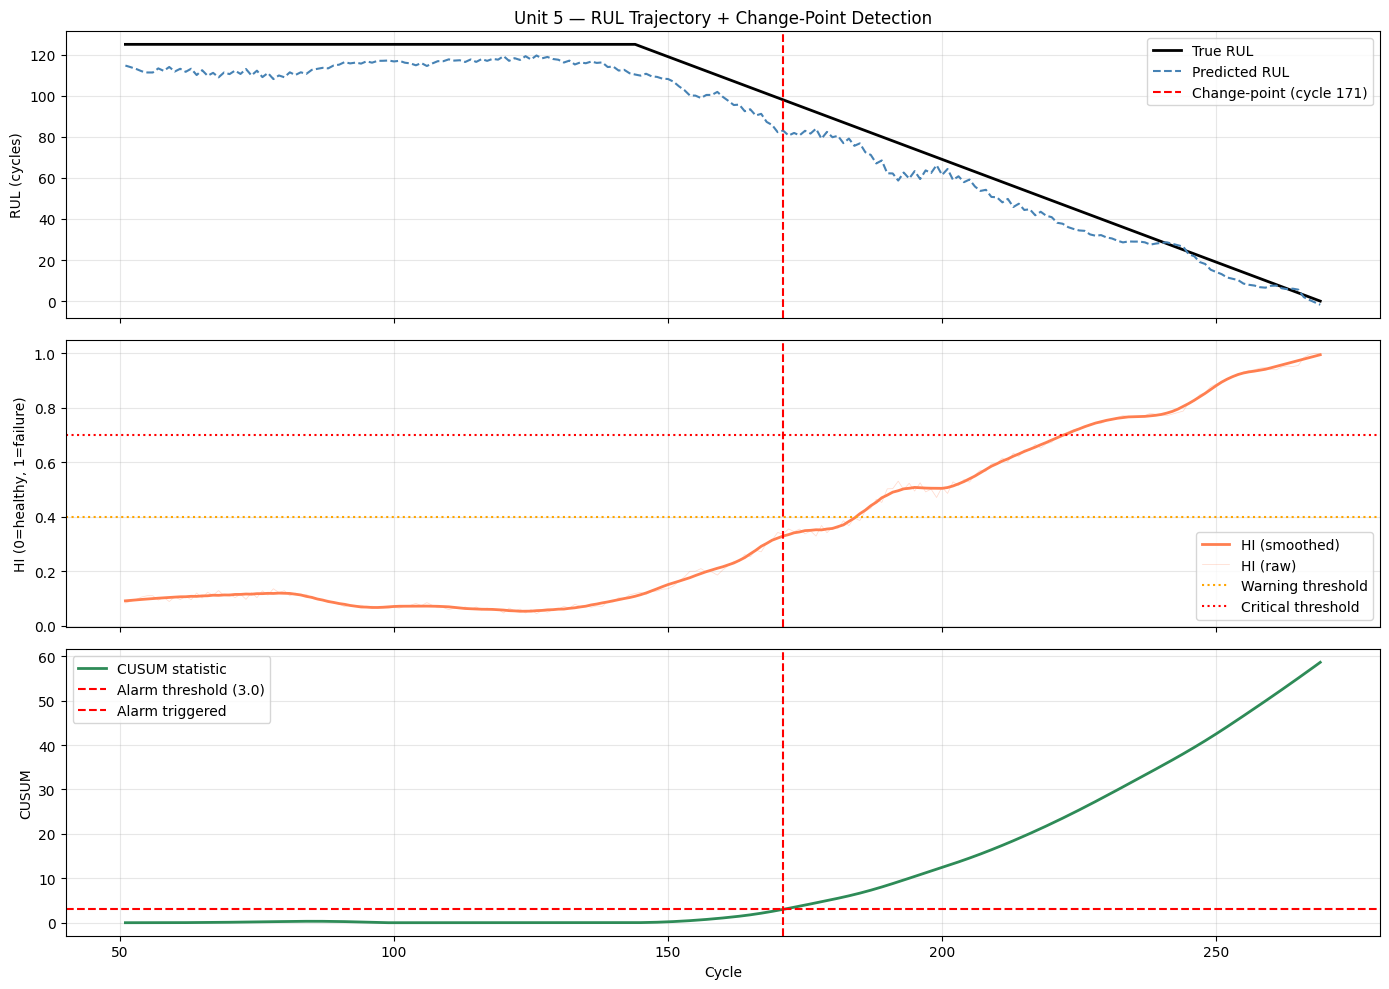


Operator alert message:
  ALERT — Unit 5: Degradation detected at cycle 171.
  Estimated remaining life: 83 cycles.
  Primary contributors: ['sensor_4', 'sensor_8']
  Recommended action: Warning


In [29]:
# ── CELL 16: CUSUM change-point detection ────────────────────────────────────
CP_UNIT      = 5
CUSUM_THRESH = 3.0
CUSUM_DRIFT  = 0.1

cp_run_df = df_tr[df_tr['unit_id'] == CP_UNIT].sort_values('cycle')
X_cp      = create_windows_for_unit_lifecycle(cp_run_df, FEATURE_COLS, WINDOW_SIZE_CNN)
X_cp      = X_cp.astype(np.float32)
cycles_cp = cp_run_df['cycle'].values[WINDOW_SIZE_CNN:]
true_rul  = cp_run_df['RUL'].values[WINDOW_SIZE_CNN:]

pred_rul_cp = cnn_model.predict(X_cp, verbose=0).flatten() * MAX_RUL

hi_cp_raw = 1.0 - np.clip(pred_rul_cp / MAX_RUL, 0, 1)
hi_cp     = np.clip(savgol_filter(hi_cp_raw, window_length=21, polyorder=2), 0, 1)

# cusum_detector returns a single int (change-point index), not a tuple.
# Reconstruct the CUSUM statistic series manually for the plot.
cp_idx = cusum_detector(
    series    = hi_cp,
    threshold = CUSUM_THRESH,
    drift     = CUSUM_DRIFT
)

# derive cp_idx FROM the reconstruction so both always agree:
cusum_series = np.zeros(len(hi_cp))
for t in range(1, len(hi_cp)):
    cusum_series[t] = max(0.0, cusum_series[t-1] + (hi_cp[t] - CUSUM_DRIFT))

# Find first threshold crossing directly from the series we plot
# This guarantees the vertical line and the CUSUM curve always agree
crossings = np.where(cusum_series >= CUSUM_THRESH)[0]
cp_idx    = int(crossings[0]) if len(crossings) > 0 else len(cycles_cp)
cp_cycle  = cycles_cp[cp_idx] if cp_idx < len(cycles_cp) else None
cp_rul    = pred_rul_cp[cp_idx] if cp_idx < len(pred_rul_cp) else 0.0
cp_true_rul = true_rul[cp_idx] if cp_idx < len(true_rul) else 0.0

health_at_cp = classify_health_state(
    rul_prediction        = cp_rul,
    change_point_detected = True,
    critical_rul          = 20,
    warning_rul           = 50
)

print(f'Unit {CP_UNIT}: Change-point detected at cycle {cp_cycle}')
print(f'Health state at transition: {health_at_cp}')
print(f'True RUL at change-point:   {cp_true_rul:.1f} cycles')

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(cycles_cp, true_rul,   'k-',       linewidth=2,   label='True RUL')
axes[0].plot(cycles_cp, pred_rul_cp,'steelblue', linewidth=1.5, linestyle='--',
             label='Predicted RUL')
if cp_cycle:
    axes[0].axvline(cp_cycle, color='red', linestyle='--',
                    label=f'Change-point (cycle {cp_cycle})')
axes[0].set_ylabel('RUL (cycles)')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title(f'Unit {CP_UNIT} — RUL Trajectory + Change-Point Detection')

axes[1].plot(cycles_cp, hi_cp,     'coral', linewidth=2,   label='HI (smoothed)')
axes[1].plot(cycles_cp, hi_cp_raw, 'coral', linewidth=0.5, alpha=0.3, label='HI (raw)')
if cp_cycle:
    axes[1].axvline(cp_cycle, color='red', linestyle='--')
axes[1].axhline(0.4, color='orange', linestyle=':', label='Warning threshold')
axes[1].axhline(0.7, color='red',    linestyle=':', label='Critical threshold')
axes[1].set_ylabel('HI (0=healthy, 1=failure)')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(cycles_cp, cusum_series, 'seagreen', linewidth=2, label='CUSUM statistic')
axes[2].axhline(CUSUM_THRESH, color='red', linestyle='--',
                label=f'Alarm threshold ({CUSUM_THRESH})')
if cp_cycle:
    axes[2].axvline(cp_cycle, color='red', linestyle='--', label='Alarm triggered')
axes[2].set_xlabel('Cycle'); axes[2].set_ylabel('CUSUM')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('\nOperator alert message:')
print(f'  ALERT — Unit {CP_UNIT}: Degradation detected at cycle {cp_cycle}.')
print(f'  Estimated remaining life: {cp_rul:.0f} cycles.')
print(f'  Primary contributors: {feature_importance.head(2).index.tolist()}')
print(f'  Recommended action: {health_at_cp}')

Change-point detected in 30/30 units
Mean detection at 1.3% of lifecycle
Mean RUL at detection: 114.4 cycles


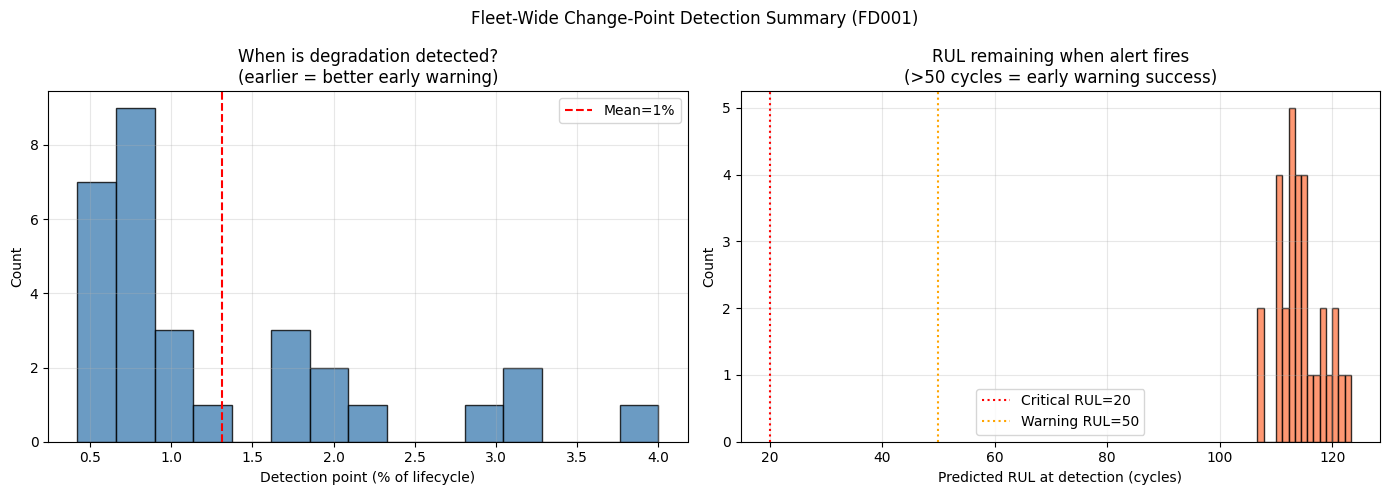

In [30]:
# ── CELL 17: Fleet-wide change-point summary ──────────────────────────────────
cp_results = []
for uid in sorted(df_tr['unit_id'].unique())[:30]:
    run_df_u = df_tr[df_tr['unit_id'] == uid].sort_values('cycle')
    if len(run_df_u) < WINDOW_SIZE_CNN + 5:
        continue
    X_u      = create_windows_for_unit_lifecycle(run_df_u, FEATURE_COLS, WINDOW_SIZE_CNN)
    cycles_u = run_df_u['cycle'].values[WINDOW_SIZE_CNN:]
    pred_u   = cnn_model.predict(X_u.astype(np.float32), verbose=0).flatten() * MAX_RUL
    hi_u     = 1.0 - np.clip(pred_u / MAX_RUL, 0, 1)
    if len(hi_u) >= 21:
        hi_u = np.clip(savgol_filter(hi_u, 21, 2), 0, 1)

    # FIX: cusum_detector returns a single int, not a tuple
    cp_u  = cusum_detector(hi_u, threshold=CUSUM_THRESH, drift=CUSUM_DRIFT)
    total = len(cycles_u)

    cp_results.append({
        'unit_id':  uid,
        'cp_idx':   cp_u,
        'cp_cycle': cycles_u[cp_u] if cp_u < total else None,
        'life_pct': cp_u / total * 100 if cp_u < total else 100,
        'rul_at_cp':pred_u[cp_u] if cp_u < total else 0,
    })

df_cp    = pd.DataFrame(cp_results)
detected = df_cp[df_cp['cp_cycle'].notna()]

print(f'Change-point detected in {len(detected)}/{len(df_cp)} units')
print(f'Mean detection at {detected["life_pct"].mean():.1f}% of lifecycle')
print(f'Mean RUL at detection: {detected["rul_at_cp"].mean():.1f} cycles')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(detected['life_pct'], bins=15, color='steelblue',
             edgecolor='black', alpha=0.8)
axes[0].axvline(detected['life_pct'].mean(), color='red', linestyle='--',
                label=f'Mean={detected["life_pct"].mean():.0f}%')
axes[0].set_xlabel('Detection point (% of lifecycle)')
axes[0].set_ylabel('Count')
axes[0].set_title('When is degradation detected?\n(earlier = better early warning)')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(detected['rul_at_cp'].dropna(), bins=15, color='coral',
             edgecolor='black', alpha=0.8)
axes[1].axvline(20, color='red',    linestyle=':', label='Critical RUL=20')
axes[1].axvline(50, color='orange', linestyle=':', label='Warning RUL=50')
axes[1].set_xlabel('Predicted RUL at detection (cycles)')
axes[1].set_ylabel('Count')
axes[1].set_title('RUL remaining when alert fires\n(>50 cycles = early warning success)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Fleet-Wide Change-Point Detection Summary (FD001)', fontsize=12)
plt.tight_layout()
plt.show()